## EDA 

Análise exploratória do dataset application_train.csv, focado em encontrar variáveis que sirvam como features para um modelo preditivo

In [1]:
from src.config import DIR_ROOT, DATA_DIR_RAW
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter


## Leitura inicial dos dados

leitura do csv e obervação inicial dos dados

In [2]:
df_application_train = pd.read_csv(DATA_DIR_RAW / "application_train.csv")

In [3]:
#Visualização inicial dos dados
df_application_train.head(10)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
#Visualizando valores nulos e colunas
df_application_train.isnull().mean()

SK_ID_CURR                    0.000000
TARGET                        0.000000
NAME_CONTRACT_TYPE            0.000000
CODE_GENDER                   0.000000
FLAG_OWN_CAR                  0.000000
                                ...   
AMT_REQ_CREDIT_BUREAU_DAY     0.135016
AMT_REQ_CREDIT_BUREAU_WEEK    0.135016
AMT_REQ_CREDIT_BUREAU_MON     0.135016
AMT_REQ_CREDIT_BUREAU_QRT     0.135016
AMT_REQ_CREDIT_BUREAU_YEAR    0.135016
Length: 122, dtype: float64

In [5]:
#Informações sobre o dataset
# 307511 linhas e 122 colunas
df_application_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [6]:
df_application_train['TARGET'].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

In [7]:

numeric_columns = df_application_train.select_dtypes(include=np.number).columns

print(f'Colunas numéricas: {len(numeric_columns)}')

categoric_columns = df_application_train.select_dtypes(include='str').columns
print(f'Colunas categóricas: {len(categoric_columns)}')

Colunas numéricas: 106
Colunas categóricas: 16


In [8]:
# Colunas numéricas com valores nulos em ordem decrescente
df_aux = df_application_train[numeric_columns].isnull().mean()
display(df_aux.sort_values(ascending=False).head(10))

COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_MEDI       0.683550
FLOORSMIN_AVG               0.678486
dtype: float64

In [9]:
# Colunas categóricas com valores nulos em ordem decrescente
df_aux_categoricas = df_application_train[categoric_columns].isnull().mean()
display(df_aux_categoricas.sort_values(ascending=False).head(10))

FONDKAPREMONT_MODE     0.683862
WALLSMATERIAL_MODE     0.508408
HOUSETYPE_MODE         0.501761
EMERGENCYSTATE_MODE    0.473983
OCCUPATION_TYPE        0.313455
NAME_TYPE_SUITE        0.004201
FLAG_OWN_CAR           0.000000
NAME_CONTRACT_TYPE     0.000000
NAME_FAMILY_STATUS     0.000000
NAME_EDUCATION_TYPE    0.000000
dtype: float64

In [10]:
df_bureau = pd.read_csv(DATA_DIR_RAW / "bureau.csv")

In [11]:
df_bureau.info()

<class 'pandas.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           str    
 3   CREDIT_CURRENCY         str    
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             str    
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), str(3)
memory usage: 222.6 MB


In [12]:
df_bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [13]:
bureau_per_client = df_bureau.groupby('SK_ID_CURR').agg(
    num_previous_credit = pd.NamedAgg(column='SK_ID_CURR', aggfunc='count'),
    avg_credit_amount = pd.NamedAgg(column='AMT_CREDIT_SUM', aggfunc='mean'),
    most_recent_credit_days = pd.NamedAgg(column='DAYS_CREDIT', aggfunc='max'))

In [14]:
bureau_per_client.head()

,num_previous_credit,avg_credit_amount,most_recent_credit_days
SK_ID_CURR,,,
100001,7,207623.571429,-49
100002,8,108131.945625,-103
100003,4,254350.125000,-606
100004,2,94518.900000,-408
100005,3,219042.000000,-62


In [15]:
df_merged = df_application_train.merge(
    bureau_per_client, how='left', left_on='SK_ID_CURR', right_on='SK_ID_CURR') 

In [16]:

df_merged.groupby('TARGET')['avg_credit_amount'].mean()

TARGET
0    383230.739263
1    316600.958111
Name: avg_credit_amount, dtype: float64

In [17]:
df_merged.groupby("TARGET")[["num_previous_credit", "avg_credit_amount"]].mean()

,num_previous_credit,avg_credit_amount
TARGET,,
0,5.556056,383230.739263
1,5.622545,316600.958111


In [41]:
df_merged['TARGET'].isnull().sum()

np.int64(0)

In [19]:
# Descrição das colunas do dataset
desc = pd.read_csv(DATA_DIR_RAW / "HomeCredit_columns_description.csv", encoding='latin-1')
desc[desc["Table"] == "application_{train|test}.csv"][["Row", "Description"]].head(50)


,Row,Description
0,SK_ID_CURR,ID of loan in our sample
1,TARGET,Target variable (1 - client with payment diffi...
2,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving
3,CODE_GENDER,Gender of the client
4,FLAG_OWN_CAR,Flag if the client owns a car
5,FLAG_OWN_REALTY,Flag if client owns a house or flat
6,CNT_CHILDREN,Number of children the client has
7,AMT_INCOME_TOTAL,Income of the client
8,AMT_CREDIT,Credit amount of the loan
9,AMT_ANNUITY,Loan annuity


In [20]:
df_application_train.groupby("TARGET")[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].mean()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
TARGET,,,
0,0.511461,0.523479,0.520969
1,0.386968,0.410935,0.390717


In [21]:
df_application_train = df_application_train.assign(
    credit_to_income=df_application_train["AMT_CREDIT"] / df_application_train["AMT_INCOME_TOTAL"],
    annuity_to_income=df_application_train["AMT_ANNUITY"] / df_application_train["AMT_INCOME_TOTAL"],
)

C:\Users\Guilherme\AppData\Local\Temp\ipykernel_1248\438654144.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_application_train = df_application_train.assign(


C:\Users\Guilherme\AppData\Local\Temp\ipykernel_1248\1119267981.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_application_train['credit_to_income_decile'] = pd.qcut(df_application_train["credit_to_income"], q = 10)


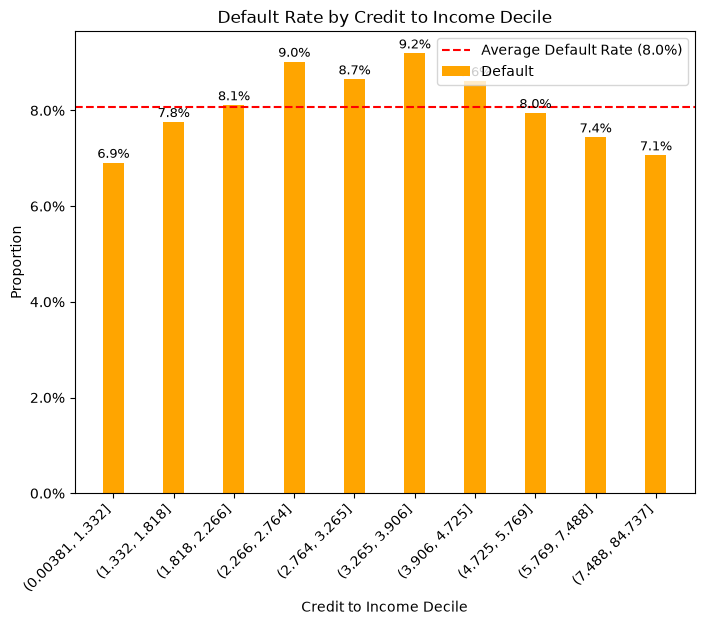

In [22]:
# Visualização de proporção de inadimplência por decil da relação crédito/renda
"""
Os dados seguem uma distribuição de sino, com risco baixo nos extremos e risco mais alto no meio.
Isso pode indicar que clientes com com o ratio (credito/renda) mais baixo são mais conservadores e menos propensos a inadimplência, o emprestimo não corresponde a uma grande parte da sua renda anual.
Já os clientes com ratios mais altos, podem ter uma renda maior e por isso são selecionados pelo banco para obter esse crédito, garantindo um menor número de inadimplentes.

O problema dessa feature é que ela não separa bem os diferentes tipos de emprestimos, 
ela não leva em consideração o tempo de pagamento do valor, ou seja um emprestimo alto pensado para 5 anos pode ter um ratio similar 
a um emprestimo médio/baixo em um período menor, por isso vai ser levado em consideração a feature "annuity_to_income" que leva em consideração
a parcela do emprestimo paga anualmente, e não o valor total do emprestimo.
"""
df_application_train['credit_to_income_decile'] = pd.qcut(df_application_train["credit_to_income"], q = 10)

proportions = pd.crosstab(df_application_train['credit_to_income_decile'], df_application_train['TARGET'], normalize='index')

fig, ax = plt.subplots(figsize=(8, 6))


x = np.arange(len(proportions.index))
ax.bar(x, proportions[1], width=0.35, color='orange', label='Default', data = proportions)
plt.axhline(y=proportions[1].mean(), color='red', linestyle='--', label='Average Default Rate (8.0%)')
ax.set_xticks(x)
ax.set_xticklabels(
    proportions.index.astype(str),
    rotation = 45,
    ha = 'right'
)
for i, v in enumerate(proportions[1]):
    ax.text(i, v + 0.001, f"{v:.1%}", ha='center', fontsize=9)
ax.set_xlabel('Credit to Income Decile')
ax.set_ylabel('Proportion')
ax.set_title('Default Rate by Credit to Income Decile')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()

C:\Users\Guilherme\AppData\Local\Temp\ipykernel_1248\598069948.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_application_train['annuity_to_income_decile'] = pd.qcut(df_application_train["annuity_to_income"], q = 10)


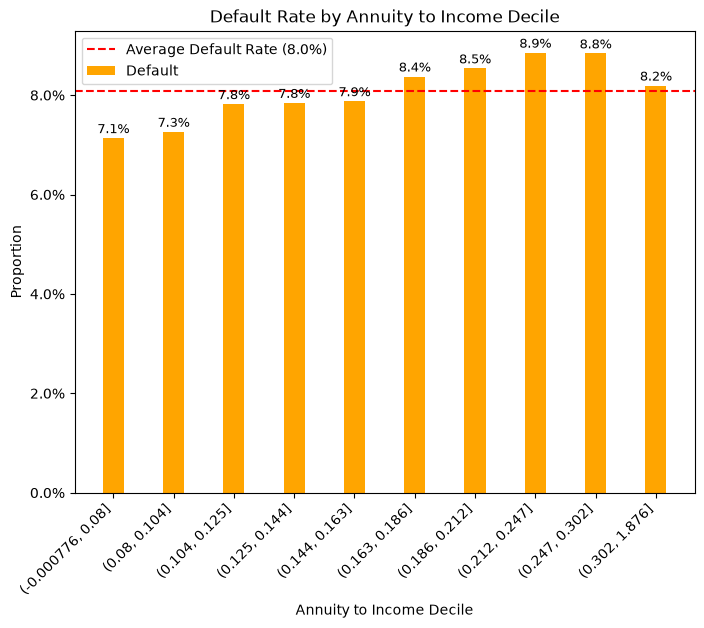

In [23]:
# Proporção da taxa de inadimplência por decil da relação parcela_anual/renda_anual
"""
Threshold empírico de 16%, significativamente abaixo dos padrões regulatórios de mercado (30-43%), possivelmente devido a origem dos dados serem de mercados emergentes
Temos uma distribuição linear até a inflexão encontrada em D9, apresentando uma relação positiva
"""
df_application_train['annuity_to_income_decile'] = pd.qcut(df_application_train["annuity_to_income"], q = 10)

annuity_proportions = pd.crosstab(df_application_train['annuity_to_income_decile'], df_application_train['TARGET'], normalize='index')

fig, ax = plt.subplots(figsize=(8, 6))


x = np.arange(len(annuity_proportions.index))
ax.bar(x , annuity_proportions[1], width=0.35, color='orange', label='Default', data = annuity_proportions)
plt.axhline(y=annuity_proportions[1].mean(), color='red', linestyle='--', label='Average Default Rate (8.0%)')
ax.set_xticks(x)
for i, v in enumerate(annuity_proportions[1]):
    ax.text(i, v + 0.001, f"{v:.1%}", ha='center', fontsize=9)
ax.set_xticklabels(
    annuity_proportions.index.astype(str),
    rotation = 45,
    ha = 'right'
    )
ax.set_xlabel('Annuity to Income Decile')
ax.set_ylabel('Proportion')
ax.set_title('Default Rate by Annuity to Income Decile')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()

# Criação de Features e teste

Criando hipóteses e verificando como ela se comporta em relação ao 'TARGET' buscando correlação para o default

In [24]:
"""
Análise de possíveis features para análise de risco de crédito:

CNT_CHIELDREN / INCOME_TOTAL -> possível feature para análise de risco
AMT_CREDIT / AMT_GOODS_PRICE -> possível feature, compara o valor do bem que vai ser adquirido com o valor do emprestimo
AMT_GOODS_PRICE  / INCOME_TOTAL -> possível feature, valor do bem que vai ser adquirido pelo valor que o cliente recebe de renda anual
'NAME_CONTRACT_TYPE' -> variável importante


"""
df_description = desc[desc['Table'] == 'application_{train|test}.csv'][["Row", "Description"]].head(50)

df_description.head(100)


# df_description[df_description['Row'] == 'AMT_GOODS_PRICE'].values[0]

,Row,Description
0,SK_ID_CURR,ID of loan in our sample
1,TARGET,Target variable (1 - client with payment diffi...
2,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving
3,CODE_GENDER,Gender of the client
4,FLAG_OWN_CAR,Flag if the client owns a car
5,FLAG_OWN_REALTY,Flag if client owns a house or flat
6,CNT_CHILDREN,Number of children the client has
7,AMT_INCOME_TOTAL,Income of the client
8,AMT_CREDIT,Credit amount of the loan
9,AMT_ANNUITY,Loan annuity


In [25]:
"""
Cash loans apresenta aproximadamente 90,4% dos casos no dataset (278232 emprestimos)
Revolving Loans apresenta aproximadamente 9,5 % dos casos no dataset (29279 emprestimos)

nesse caso o número de inadimplencia tende a ser menor em Revolving Loans devido a alta taxa de juros associados e a maneira de cobrança que 
é recorrente onde o cliente paga apenas o que foi utilizado no mês

"""


df_application_train['NAME_CONTRACT_TYPE'].value_counts(normalize = 'True')

type_contract_per_target = pd.crosstab(df_application_train['NAME_CONTRACT_TYPE'], df_application_train['TARGET'], normalize = 'index')

display(type_contract_per_target.style.format("{:.2f}"))

print(df_application_train['NAME_CONTRACT_TYPE'].value_counts(normalize= True)
)

TARGET,0,1
NAME_CONTRACT_TYPE,,
Cash loans,0.92,0.08
Revolving loans,0.95,0.05


NAME_CONTRACT_TYPE
Cash loans         0.904787
Revolving loans    0.095213
Name: proportion, dtype: float64


In [ ]:
# visualização do target para years_employed
print(df_application_train.groupby("TARGET")['DAYS_EMPLOYED'].mean())

# Max tem um valor muito a cima, isso se deve a carácterística do dataset em colocar o valor 365243 dias para clientes informais/aposentados
print(df_application_train['DAYS_EMPLOYED'].describe())


df_application_train["flag_employed"] = (
    df_application_train["DAYS_EMPLOYED"] != 365243
).astype(int)

df_application_train["DAYS_EMPLOYED"] = (
    df_application_train["DAYS_EMPLOYED"]
    .replace(365243, np.nan)
)

df_application_train['years_employed'] = (
     df_application_train['DAYS_EMPLOYED'] / 365
)

# verificando se o nan foi aplicado 
print("-" * 100)
print(df_application_train['DAYS_EMPLOYED'].isna().sum())


TARGET
0   -2438.140133
1   -1814.918800
Name: DAYS_EMPLOYED, dtype: float64
count    252137.000000
mean      -2384.169325
std        2338.360162
min      -17912.000000
25%       -3175.000000
50%       -1648.000000
75%        -767.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64
----------------------------------------------------------------------------------------------------
55374


In [ ]:
df_application_train.groupby("TARGET")['flag_employed'].mean()

df_application_train.groupby("TARGET")['yeras_employed'].mean()